# MathEBT — tests de compréhension mathématique (checkpoint step 20000)

Ce modèle est un **encodeur** (DINO), pas un modèle génératif : il ne "répond" pas à des questions. Sa compréhension se mesure dans la **structure de son espace latent**. Cinq tests, du plus direct au plus exigeant :

1. **Invariance certifiée** — une déclaration et sa vue certifiée (alpha-renommage, impression explicite, permutation d'hypothèses) doivent être proches ; deux déclarations sans rapport doivent être loin.
2. **Regroupement par concept** — les énoncés de commutativité doivent se ressembler entre eux plus qu'ils ne ressemblent aux énoncés de transitivité, etc.
3. **Intrus (odd-one-out)** — parmi 3 déclarations d'un domaine + 1 d'un autre, le modèle doit isoler l'intrus.
4. **Voisins les plus proches** — inspection qualitative : les voisins d'une déclaration sont-ils thématiquement liés ?
5. **Séparation des domaines** — projection 2D des latents colorée par domaine Mathlib.

Tous les énoncés de test viennent du **split test réel** (jamais vu à l'entraînement, split par fichier + dédup AST — invariant 7 de docs/DESIGN.md), dans le format exact vu à l'entraînement (`[PROOF] type [SEP]`). Pas d'énoncés inventés à la main : ils seraient hors distribution (le corpus utilise le style pretty-print Lean `Eq (instHAdd.hAdd a b) ...`, pas `a + b = b + a`).

In [2]:
import json
import random
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO = Path.cwd()
if not (REPO / 'src' / 'math_ebt').exists():
    raise SystemExit('Lance ce notebook depuis la racine du repo math_ebt')
sys.path.insert(0, str(REPO / 'src'))

from math_ebt.config import Config
from math_ebt.tokenization import load_tokenizer
from math_ebt.data.schema import read_jsonl
from math_ebt.models.dino import DINOModel
from math_ebt.utils.device import best_device

CKPT_PATH = 'model/model_20000_step.pt'
CONFIG_PATH = 'configs/dino_v0.yaml'
SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
device = best_device()
cfg = Config.load(CONFIG_PATH)
tok = load_tokenizer(cfg)  # fixe aussi cfg.model.vocab_size (33464)

model = DINOModel(cfg).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"device={device}  checkpoint step={ckpt['step']}  vocab={cfg.model.vocab_size}")
del ckpt  # l'optimizer dans le checkpoint pèse ~300MB, inutile ici

device=mps  checkpoint step=20000  vocab=33464


In [4]:
@torch.no_grad()
def encode(texts: list[str], bs: int = 64, max_len: int | None = None) -> torch.Tensor:
    """Latents L2-normalisés (teacher backbone, pré-projection — le latent aval documenté)."""
    max_len = max_len or cfg.data.max_seq_len
    tok.enable_truncation(max_length=max_len)
    tok.enable_padding(pad_id=tok.token_to_id('[PAD]'), pad_token='[PAD]')
    out = []
    for i in range(0, len(texts), bs):
        enc = tok.encode_batch(texts[i:i + bs])
        ids = torch.tensor([e.ids for e in enc], device=device)
        mask = torch.tensor([e.attention_mask for e in enc], device=device)
        out.append(model.encode(ids, mask).float().cpu())
    return F.normalize(torch.cat(out), dim=-1)


def fmt(d) -> str:
    return d.type_only_text()  # '[PROOF] {type_implicit} [SEP]' — le format d'évaluation

## Chargement du split test

On sous-échantillonne pour que tout tourne en quelques minutes sur MPS/CPU.

In [5]:
test_decls = list(read_jsonl('data/splits/test.jsonl'))
print(f'{len(test_decls)} déclarations de test')

N_ANCHORS = 1200   # test d'invariance
N_CORPUS = 4000    # corpus de recherche pour voisins/intrus

rng = random.Random(SEED)
corpus = rng.sample(test_decls, N_CORPUS)
anchors = [d for d in rng.sample(test_decls, 3 * N_ANCHORS) if d.type_alpha][:N_ANCHORS]
print(f'{len(anchors)} ancres avec vue alpha, corpus de {len(corpus)}')

31228 déclarations de test
1200 ancres avec vue alpha, corpus de 4000


## Test 1 — invariance aux vues certifiées

Pour chaque ancre : similarité avec sa vue alpha-renommée, sa vue explicite, sa permutation d'hypothèses (quand elle existe), et une déclaration aléatoire. Un modèle qui "comprend" doit mettre les trois premières très haut et la dernière nettement plus bas — en valeurs **absolues** (cf. la leçon du ratio abandonné dans le README).

alpha-renommage              mean=0.9793  p10=0.9588  p90=0.9969
impression explicite         mean=0.9817  p10=0.9627  p90=0.9980
permutation hyp. (n=1011)    mean=0.9992  p10=0.9982  p90=1.0000
paire aléatoire              mean=0.1264  p10=-0.3918  p90=0.6860


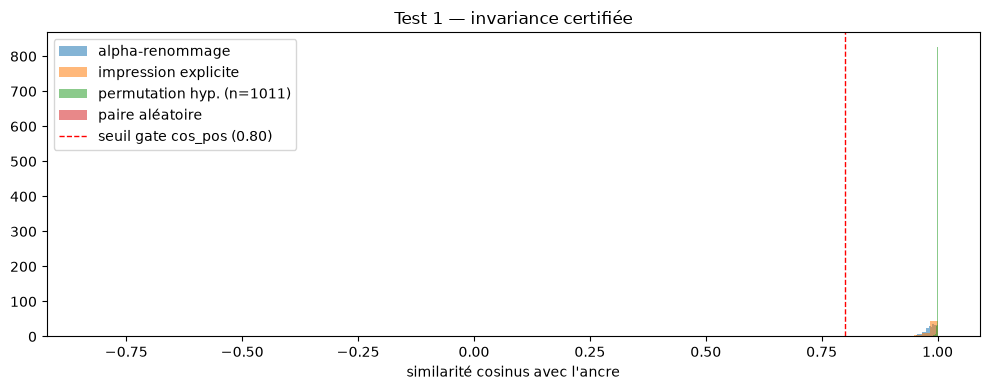


fraction des vues alpha au-dessus du max aléatoire : 14.7%


In [6]:
z_anchor = encode([fmt(d) for d in anchors])
z_alpha = encode([f'[PROOF] {d.type_alpha} [SEP]' for d in anchors])
z_expl = encode([f'[PROOF] {d.type_explicit} [SEP]' for d in anchors])

perm_idx = [i for i, d in enumerate(anchors) if d.type_perm_hyp]
z_perm = encode([f'[PROOF] {anchors[i].type_perm_hyp} [SEP]' for i in perm_idx])

shuffled = list(range(len(anchors)))
rng.shuffle(shuffled)
shuffled = [j if j != i else (j + 1) % len(anchors) for i, j in enumerate(shuffled)]

cos_alpha = (z_anchor * z_alpha).sum(-1)
cos_expl = (z_anchor * z_expl).sum(-1)
cos_perm = (z_anchor[perm_idx] * z_perm).sum(-1)
cos_rand = (z_anchor * z_anchor[shuffled]).sum(-1)

results_t1 = {
    'alpha-renommage': cos_alpha, 'impression explicite': cos_expl,
    f'permutation hyp. (n={len(perm_idx)})': cos_perm, 'paire aléatoire': cos_rand,
}
for name, c in results_t1.items():
    print(f'{name:28s} mean={c.mean():.4f}  p10={c.quantile(0.1):.4f}  p90={c.quantile(0.9):.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
for name, c in results_t1.items():
    ax.hist(c.numpy(), bins=60, alpha=0.55, label=name, density=True)
ax.axvline(0.80, color='red', ls='--', lw=1, label='seuil gate cos_pos (0.80)')
ax.set_xlabel('similarité cosinus avec l\'ancre'); ax.legend(); ax.set_title('Test 1 — invariance certifiée')
plt.tight_layout(); plt.show()

# Séparabilité : quelle fraction des paires certifiées bat la PIRE paire aléatoire ?
sep = (cos_alpha > cos_rand.max()).float().mean()
print(f'\nfraction des vues alpha au-dessus du max aléatoire : {sep:.1%}')

## Test 2 — regroupement par concept mathématique

On sélectionne des déclarations réelles par motif de nom (commutativité, associativité, transitivité, injectivité, continuité…) et on mesure si la similarité **intra-concept** dépasse la similarité **inter-concepts**. C'est un test de compréhension plus fort que l'invariance : les énoncés d'un même concept ne partagent pas leur forme de surface (ils portent sur des types différents).

In [7]:
# Matching par SUFFIXE ou segment complet ('..._comm', '..._comm_...'), pas par
# simple sous-chaîne : '_trans' en sous-chaîne attrape 'support_translate'
# (translation, pas transitivité) et '_comm' attrape 'forget₂_commAlgCat_map'
# (algèbre commutative, pas un lemme de commutativité) -- constaté sur une
# première passe de ce notebook.
CONCEPTS = {
    'commutativité': ['_comm'],
    'associativité': ['_assoc'],
    'transitivité': ['_trans'],
    'injectivité': ['_injective'],
    'monotonie': ['_mono', '_monotone'],
    'continuité': ['_continuous', 'continuous'],
    'mesurabilité': ['_measurable', 'measurable'],
}
PER_CONCEPT = 12


def matches(name: str, pat: str) -> bool:
    n = name.lower()
    return n.endswith(pat) or (pat + '_') in n or n == pat.lstrip('_') or n.startswith(pat.lstrip('_') + '_')


by_concept: dict[str, list] = {}
used = set()
for cname, pats in CONCEPTS.items():
    picks = []
    for d in test_decls:
        if d.decl_name not in used and any(matches(d.decl_name, p) for p in pats):
            picks.append(d); used.add(d.decl_name)
        if len(picks) == PER_CONCEPT:
            break
    by_concept[cname] = picks
    print(f'{cname:16s} {len(picks):3d} déclarations  ex: {[p.decl_name for p in picks[:3]]}')

concept_names = [c for c, ds in by_concept.items() if len(ds) >= 6]
flat = [(c, d) for c in concept_names for d in by_concept[c]]
z_concepts = encode([fmt(d) for _, d in flat])
labels = np.array([concept_names.index(c) for c, _ in flat])

commutativité     12 déclarations  ex: ['frobenius_comm', 'iterateFrobenius_comm', 'mul_comm']
associativité     12 déclarations  ex: ['iso₁_hom_naturality_assoc', 'iso₀_hom_naturality_assoc', 'smul_map_assoc']
transitivité      12 déclarations  ex: ['trans', 'aux_trans', 'mul_eq_trans']
injectivité       12 déclarations  ex: ['toRatAlgEquiv_injective', 'restrictScalars_injective', 'lmap_injective']
monotonie         12 déclarations  ex: ['single_mono', 'one_mono', 'zero_mono']
continuité        12 déclarations  ex: ['instIsRightAdjointPushforwardCompSheafRingCatMapSheafPushforwardContinuous', 'continuous', 'continuous_cfcₙAux']
mesurabilité      12 déclarations  ex: ['measurable_embeddingReal', 'exists_eq_measurable_comp', 'memLp_zero_iff_aestronglyMeasurable']


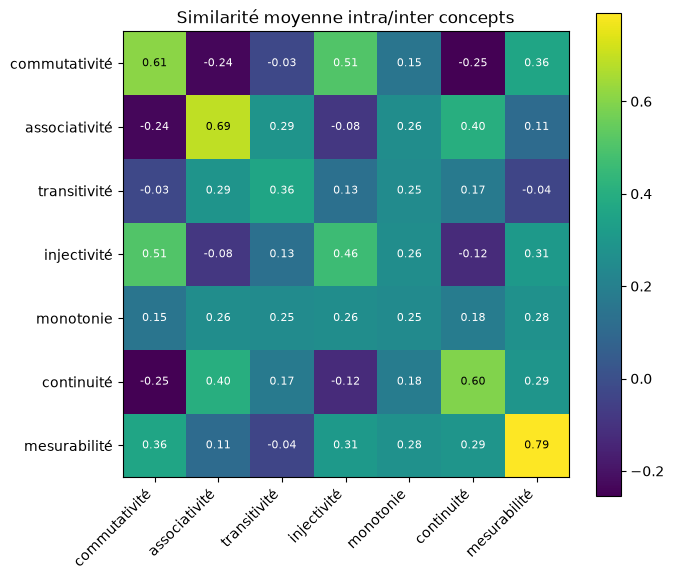

intra-concept moyen : 0.5371
inter-concepts moyen: 0.1522
marge               : +0.3849  (>0 = les concepts existent dans le latent)
concepts où l'intra bat tout l'inter : 5/7


In [8]:
sim = (z_concepts @ z_concepts.T).numpy()
K = len(concept_names)
block = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        mi, mj = labels == i, labels == j
        s = sim[np.ix_(mi, mj)]
        if i == j:
            n = mi.sum()
            block[i, j] = (s.sum() - n) / max(n * n - n, 1)  # sans la diagonale
        else:
            block[i, j] = s.mean()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(block, cmap='viridis')
ax.set_xticks(range(K), concept_names, rotation=45, ha='right')
ax.set_yticks(range(K), concept_names)
for i in range(K):
    for j in range(K):
        ax.text(j, i, f'{block[i, j]:.2f}', ha='center', va='center',
                color='white' if block[i, j] < block.max() * 0.7 else 'black', fontsize=8)
fig.colorbar(im); ax.set_title('Similarité moyenne intra/inter concepts')
plt.tight_layout(); plt.show()

intra = np.diag(block).mean()
inter = block[~np.eye(K, dtype=bool)].mean()
margin_t2 = intra - inter
print(f'intra-concept moyen : {intra:.4f}')
print(f'inter-concepts moyen: {inter:.4f}')
print(f'marge               : {margin_t2:+.4f}  (>0 = les concepts existent dans le latent)')
diag_wins = sum(1 for i in range(K) if block[i, i] > np.delete(block[i], i).max())
print(f'concepts où l\'intra bat tout l\'inter : {diag_wins}/{K}')

## Test 3 — trouver l'intrus (odd-one-out)

3 déclarations d'un même module + 1 d'un domaine différent. L'intrus devrait être celle qui a la plus faible similarité moyenne aux trois autres. Chance = 25 %.

In [9]:
by_module = defaultdict(list)
for d in corpus:
    by_module[d.module].append(d)
rich_modules = [m for m, ds in by_module.items() if len(ds) >= 3]

N_TRIALS = 120
trials, correct = 0, 0
examples = []
trial_rng = random.Random(SEED + 1)

for _ in range(N_TRIALS * 3):
    if trials >= N_TRIALS:
        break
    m = trial_rng.choice(rich_modules)
    group = trial_rng.sample(by_module[m], 3)
    dom = group[0].domain_label
    others = [d for d in corpus if d.domain_label != dom]
    if not others:
        continue
    intruder = trial_rng.choice(others)
    four = group + [intruder]
    order = list(range(4)); trial_rng.shuffle(order)
    four = [four[i] for i in order]
    true_pos = order.index(3)

    z = encode([fmt(d) for d in four])
    s = z @ z.T
    avg_sim = (s.sum(-1) - 1.0) / 3.0  # similarité moyenne aux 3 autres
    pred = int(avg_sim.argmin())
    correct += int(pred == true_pos)
    trials += 1
    if len(examples) < 3:
        examples.append((four, true_pos, pred))

acc_t3 = correct / trials
print(f'odd-one-out : {correct}/{trials} = {acc_t3:.1%}  (chance = 25 %)')
for four, t, p in examples:
    ok = 'OK ' if t == p else 'RATÉ'
    print(f'\n[{ok}] intrus réel = #{t}, prédit = #{p}')
    for i, d in enumerate(four):
        tag = ' <- intrus' if i == t else ''
        print(f'  #{i} [{d.domain_label:12s}] {d.decl_name}{tag}')

odd-one-out : 112/120 = 93.3%  (chance = 25 %)

[OK ] intrus réel = #3, prédit = #3
  #0 [Analysis    ] one_le_inv_iff_le_one
  #1 [Analysis    ] norm_le_iff_le_algebraMap
  #2 [Analysis    ] cfcₙ_tsub
  #3 [Algebra     ] cokernelSequenceCyclesE_g <- intrus

[OK ] intrus réel = #3, prédit = #3
  #0 [RingTheory  ] cyclotomic_mul_prime_dvd_eq_pow
  #1 [RingTheory  ] cyclotomic_six
  #2 [RingTheory  ] cyclotomic_irreducible_of_irreducible_pow
  #3 [GroupTheory ] isCycle_cycleRange <- intrus

[OK ] intrus réel = #1, prédit = #1
  #0 [GroupTheory ] toList_formPerm_isRotated_self
  #1 [Order       ] partialOrder <- intrus
  #2 [GroupTheory ] toList_formPerm_singleton
  #3 [GroupTheory ] toList_isRotated


## Test 4 — voisins les plus proches (qualitatif)

Pour quelques requêtes, les 8 voisins les plus proches dans le corpus. À lire à l'œil : les voisins parlent-ils de la même chose ?

In [10]:
z_corpus = encode([fmt(d) for d in corpus])

queries = [d for d in corpus if any(
    p in d.decl_name.lower() for p in ('add_comm', 'mul_assoc', 'continuous', 'measurable', 'le_trans')
)][:5] or corpus[:5]

for q in queries:
    qi = corpus.index(q)
    sims = z_corpus @ z_corpus[qi]
    top = sims.argsort(descending=True)[1:9]
    print(f'\n=== {q.decl_name}  [{q.module}]')
    print(f'    {q.type_implicit[:110]}')
    for r, i in enumerate(top.tolist(), 1):
        d = corpus[i]
        print(f'  {r}. ({sims[i]:.3f}) {d.decl_name:42s} [{d.domain_label}]')


=== instCompactSpaceOfT1SpaceOfContinuousMul  [Mathlib.Topology.Algebra.Group.Basic]
    ∀ {α : Type u} [inst : Monoid α] [inst_1 : TopologicalSpace α] [T1Space α] [ContinuousMul α] [CompactSpace α],
  1. (0.992) isClosedEmbedding_embedProduct             [Topology]
  2. (0.985) coe_disjoint                               [Topology]
  3. (0.980) range_Ioi                                  [Topology]
  4. (0.979) tsub_tsub_tsub_cancel_left                 [Algebra]
  5. (0.979) tsub_add_tsub_comm                         [Algebra]
  6. (0.978) tsub_inj_right                             [Algebra]
  7. (0.978) tsub_lt_tsub_iff_left_of_le_of_le          [Algebra]
  8. (0.977) upperSemicontinuousWithinAt_univ_iff       [Topology]

=== norm_compContinuous_linearIsometry_le  [Mathlib.Analysis.Normed.Module.Multilinear.Basic]
    ∀ {𝕜 : Type u} {ι : Type v} {E : ι → Type wE} {E₁ : ι → Type wE₁} {G : Type wG} [inst : NontriviallyNormedFiel
  1. (1.000) norm_compContinuousLinearMapL_le           [

## Test 5 — séparation des domaines (PCA 2D)

Projection PCA des latents du corpus, colorée par domaine Mathlib (top 8). L'éval quantitative (probe ≈ baseline majoritaire) suggère que la séparation sera partielle — ce graphe montre *ce qui* se sépare déjà et ce qui reste mélangé.

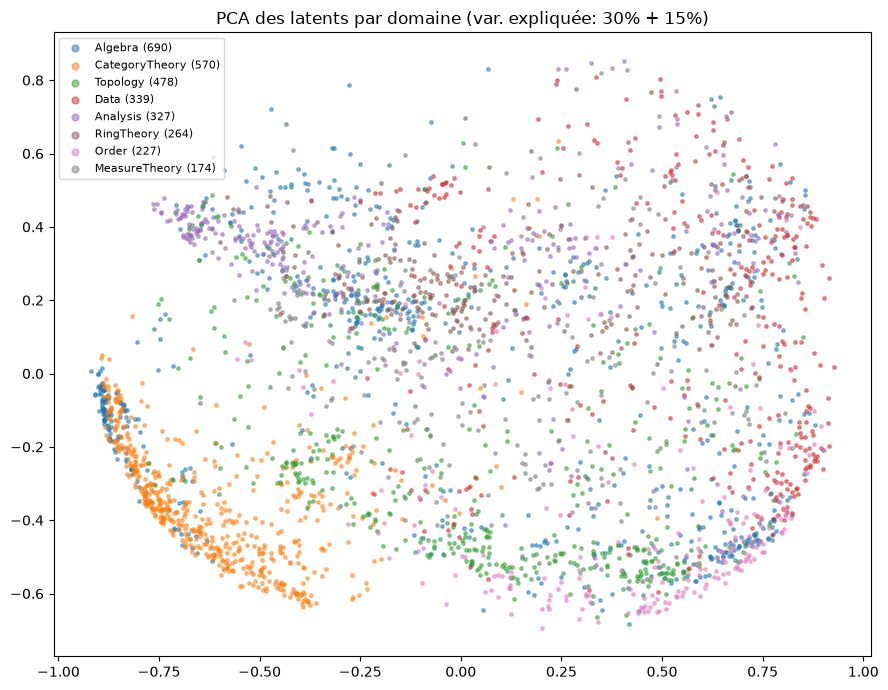

classification par centroide de domaine : 54.6%  (chance ≈ 12%)


In [11]:
domains = [d.domain_label for d in corpus]
top_domains = [x for x, _ in sorted(((v, domains.count(v)) for v in set(domains)),
                                     key=lambda kv: -kv[1])[:8]]

X = z_corpus - z_corpus.mean(0)
U, S, V = torch.pca_lowrank(X, q=2)
proj = (X @ V[:, :2]).numpy()
var_explained = (S[:2] ** 2 / (X ** 2).sum()).numpy()

fig, ax = plt.subplots(figsize=(9, 7))
for dom in top_domains:
    mask = np.array([x == dom for x in domains])
    ax.scatter(proj[mask, 0], proj[mask, 1], s=6, alpha=0.5, label=f'{dom} ({mask.sum()})')
ax.legend(markerscale=2, fontsize=8)
ax.set_title(f'PCA des latents par domaine (var. expliquée: {var_explained[0]:.0%} + {var_explained[1]:.0%})')
plt.tight_layout(); plt.show()

# Score silhouette simplifié (centroides) : distance au centroide de son domaine vs au plus proche autre
cents = {dom: z_corpus[np.array([x == dom for x in domains])].mean(0) for dom in top_domains}
cent_mat = F.normalize(torch.stack([cents[d] for d in top_domains]), dim=-1)
in_top = np.array([x in top_domains for x in domains])
zi = z_corpus[in_top]
li = torch.tensor([top_domains.index(x) for x, keep in zip(domains, in_top) if keep])
sims_c = zi @ cent_mat.T
own = sims_c[torch.arange(len(li)), li]
other = sims_c.clone(); other[torch.arange(len(li)), li] = -2
acc_t5 = (own > other.max(-1).values).float().mean().item()
print(f'classification par centroide de domaine : {acc_t5:.1%}  (chance ≈ {1/len(top_domains):.0%})')

## Synthèse

In [12]:
print('=' * 74)
print(f'{"Test":46s} {"Score":>12s} {"Référence":>14s}')
print('-' * 74)
print(f'{"1. cos(ancre, vue alpha)":46s} {cos_alpha.mean():>12.4f} {"gate: 0.80":>14s}')
print(f'{"1. cos(ancre, vue explicite)":46s} {cos_expl.mean():>12.4f} {"gate: 0.80":>14s}')
print(f'{"1. cos(ancre, permutation hyp.)":46s} {cos_perm.mean():>12.4f} {"gate: 0.80":>14s}')
print(f'{"1. cos(ancre, aléatoire)":46s} {cos_rand.mean():>12.4f} {"gate: <0.30":>14s}')
print(f'{"2. marge intra - inter concepts":46s} {margin_t2:>+12.4f} {">0 attendu":>14s}')
print(f'{"3. odd-one-out (détection intrus)":46s} {acc_t3:>12.1%} {"chance: 25%":>14s}')
print(f'{"5. classification centroide domaine":46s} {acc_t5:>12.1%} {"chance: ~12%":>14s}')
print('=' * 74)

Test                                                  Score      Référence
--------------------------------------------------------------------------
1. cos(ancre, vue alpha)                             0.9793     gate: 0.80
1. cos(ancre, vue explicite)                         0.9817     gate: 0.80
1. cos(ancre, permutation hyp.)                      0.9992     gate: 0.80
1. cos(ancre, aléatoire)                             0.1264    gate: <0.30
2. marge intra - inter concepts                     +0.3849     >0 attendu
3. odd-one-out (détection intrus)                     93.3%    chance: 25%
5. classification centroide domaine                   54.6%   chance: ~12%
